<a href="https://colab.research.google.com/github/mvsubbarao-svecw/NASSCOM-AI-FDP/blob/main/LinearAlgebraexcercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


1. Scalars, vectors, matrices & tensors

LAB EXERCISE 1 — Tensor ops: add, transpose, reshape


In [37]:
T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
print('T Dimensions:\n', T.ndim)
print('T Shape:\n', T.shape)

# 2. T + T
print('Addition of T+T:\n', T+T)

# 3. Transpose (print .T.shape) and reshape to (2, 6)
B=T.T
print('Transpose of T:\n',B)
print('Shape of T Transpose is:\n', T.shape)
print('Reshape of Transpose to (2,6):\n', B.reshape(2,6))

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
T Dimensions:
 2
T Shape:
 (3, 4)
Addition of T+T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
Transpose of T:
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
Shape of T Transpose is:
 (3, 4)
Reshape of Transpose to (2,6):
 [[ 0  4  8  1  5  9]
 [ 2  6 10  3  7 11]]


2. Dot & cross products, and norms

LAB EXERCISE 2 — L1/L2 norms + cosine similarity on 3 vector pairs

Three vector pairs are provided in pairs. For each pair (u, v):

Print the L1 and L2 norm of u.
Print the cosine similarity between u and v (reuse the cosine function above).
Which pair is the most similar? Note it in a comment.

In [38]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    print('L1 Norm of u:\n',la.norm(u,1))
    print('L2 Norm of u:\n',la.norm(u))
    # 2. cosine similarity of u and v
    print('Cosine Similarity of u and V is:\n', np.dot(u, v)/(la.norm(u)*la.norm(v)))
    # YOUR CODE HERE


# 3. Most similar pair = ?   (write your answer here)
print('Most similar pair = first Pair is the most similar pair because it has highest Cosine Similarity')

L1 Norm of u:
 2.0
L2 Norm of u:
 1.4142135623730951
Cosine Similarity of u and V is:
 0.9999999999999998
L1 Norm of u:
 6.0
L2 Norm of u:
 3.7416573867739413
Cosine Similarity of u and V is:
 0.7142857142857143
L1 Norm of u:
 2.0
L2 Norm of u:
 2.0
Cosine Similarity of u and V is:
 0.0
Most similar pair = first Pair is the most similar pair because it has highest Cosine Similarity


LAB EXERCISE 3 — Inverse, trace, and matrix tests
Using matrix M below:

Print inverse(M) and trace(M).
Verify that M @ inverse(M) is the identity (use np.allclose).
Test whether M is symmetric and whether P (provided) is orthogonal.

In [39]:
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
print('Inverse of M:\n', la.inv(M))
print('Trace of M:\n', np.trace(M))

# 2. M @ inv(M) == I ?
print('M @ inv(M) == I ?\n', np.allclose(M @ la.inv(M), I))

# 3. Is M symmetric? Is P orthogonal?
print('Is M is Symmetric M==M.T ?\n', np.allclose(M, M.T))
print('Is P is Orthogonal P.T==P ?\n', np.allclose(P.T@P, I))

Inverse of M:
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
Trace of M:
 7.0
M @ inv(M) == I ?
 True
Is M is Symmetric M==M.T ?
 True
Is P is Orthogonal P.T==P ?
 True


LAB EXERCISE 4 — Apply 2 transformations & plot
Start from the tri triangle below:

Build a scaling matrix that doubles x and halves y.
Build a rotation matrix for 45 degrees.
Apply both (one after another) and plot the original vs the transformed triangle.
Hint: reuse close_loop and the plotting pattern from 4B.

Rotated corners:
 [[ 0.     0.707  0.    -0.707]
 [ 0.     0.707  1.414  0.707]]


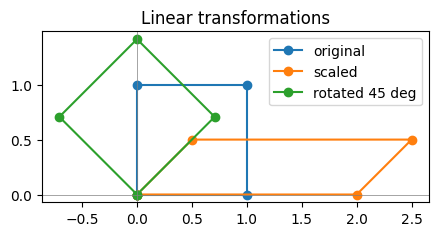

In [40]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# 1. Scaling matrix (x*2, y*0.5)
S = np.array([[2, 0.5],
              [0, 0.5]])

# 2. Rotation matrix (45 degrees)
t = np.radians(45)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])
scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)
# 3. Apply both and plot original vs transformed
def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 45 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

LAB EXERCISE 5 — Eigenvalues/vectors & verification
Using matrix C below:

Compute its eigenvalues and eigenvectors with la.eig.
Print the eigenvalues.
Verify C @ v == lambda * v for the first eigenvector using np.allclose.

In [41]:
C = np.array([[4., 1.],
              [2., 3.]])

# 1. eigenvalues and eigenvectors
vals, vecs = la.eig(C)

# 2. print eigenvalues
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)

# 3. verify A v = lambda v for the first eigenvector
for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = C @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  C v == lambda v ?', np.allclose(lhs, rhs))

Eigenvalues  (lambda): [5. 2.]
Eigenvectors (columns):
 [[ 0.707 -0.447]
 [ 0.707  0.894]]
lambda=5.0  C v == lambda v ? True
lambda=2.0  C v == lambda v ? True


6. Rank, solving systems & cosine similarity

LAB EXERCISE 6 — Solve a system + compare embeddings
Solve the 2x2 system A2 x = b2 (given below) and print x.
Print the rank of A2.
Using the embeddings, print the cosine similarity of cat vs dog, and cat vs car. Which is more similar?

In [46]:
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
x = la.solve(A2, b2)
print('Solution x:', x)

print('Full rank -> a unique solution exists')

# 2. Rank of A2
print('Rank of A2 :', la.matrix_rank(A2))

# 3. cosine(cat, dog) and cosine(cat, car); which is more similar?
def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))
print('cosine(cat, dog):\n', round(cosine(cat, dog), 3))
print('cosine(cat, car):\n', round(cosine(cat, car), 3))

print('More Similarity is Cat and Dog because it has highest cosine similarity')


Solution x: [1. 2.]
Full rank -> a unique solution exists
Rank of A2 : 2
cosine(cat, dog):
 0.995
cosine(cat, car):
 0.293
More Similarity is Cat and Dog because it has highest cosine similarity
